In [2]:
import torch
from transformers import BertForSequenceClassification, BertTokenizer

# Load with output_attentions=True — disabled by default
model = BertForSequenceClassification.from_pretrained(
    '../models/bert-imdb',
    output_attentions=True
)
tokenizer = BertTokenizer.from_pretrained('../models/bert-imdb')
model.eval()

print(f"✓ Model loaded with attention outputs")
print(f"✓ Number of layers : 12")
print(f"✓ Attention heads  : 12 per layer")
print(f"✓ Total attention matrices per input: 12 × 12 = 144")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Model loaded with attention outputs
✓ Number of layers : 12
✓ Attention heads  : 12 per layer
✓ Total attention matrices per input: 12 × 12 = 144


In [3]:
# Try both positive and negative — see how attention differs
text = "This film was absolutely terrible. Awful acting, boring plot, complete waste of time."

inputs = tokenizer(
    text,
    return_tensors='pt',
    max_length=64,        # keep short so heatmap is readable
    truncation=True
)

with torch.no_grad():
    outputs = model(**inputs)

# Get prediction
probs = torch.softmax(outputs.logits, dim=-1)[0]
pred  = "Positive 😊" if probs[1] > 0.5 else "Negative 😞"
conf  = probs.max().item()

print(f"Review   : {text}")
print(f"Prediction : {pred}")
print(f"Confidence : {conf:.4f} ({conf*100:.1f}%)")
print(f"\nAttention tensor info:")
print(f"  Number of layers : {len(outputs.attentions)}")
print(f"  Shape per layer  : {outputs.attentions[0].shape}")
print(f"  [batch, heads, seq_len, seq_len]")

Review   : This film was absolutely terrible. Awful acting, boring plot, complete waste of time.
Prediction : Negative 😞
Confidence : 0.9978 (99.8%)

Attention tensor info:
  Number of layers : 12
  Shape per layer  : torch.Size([1, 12, 19, 19])
  [batch, heads, seq_len, seq_len]


In [4]:
# Get actual tokens — these become axis labels on the heatmap
tokens = tokenizer.convert_ids_to_tokens(
    inputs['input_ids'][0].tolist()
)

print("Tokens in this review:")
for i, tok in enumerate(tokens):
    print(f"  [{i:2d}] {tok}")

Tokens in this review:
  [ 0] [CLS]
  [ 1] this
  [ 2] film
  [ 3] was
  [ 4] absolutely
  [ 5] terrible
  [ 6] .
  [ 7] awful
  [ 8] acting
  [ 9] ,
  [10] boring
  [11] plot
  [12] ,
  [13] complete
  [14] waste
  [15] of
  [16] time
  [17] .
  [18] [SEP]


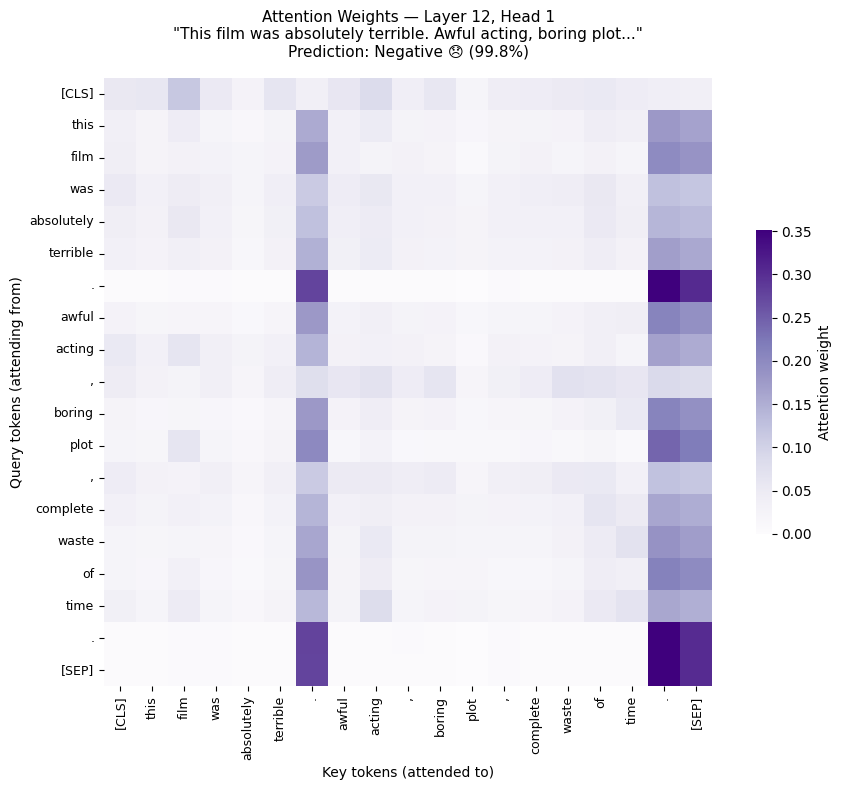

✓ Saved: data/attention_heatmap.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Layer 11 = last layer = highest-level semantic attention
# Head 0 — try different heads (0-11) to see different patterns
LAYER = 11
HEAD  = 0

attn_matrix = outputs.attentions[LAYER][0, HEAD].detach().numpy()
n_tokens    = len(tokens)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    attn_matrix,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap='Purples',
    ax=ax,
    vmin=0,
    square=True,
    cbar_kws={'shrink': 0.5, 'label': 'Attention weight'}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=9)
ax.set_title(f'Attention Weights — Layer {LAYER+1}, Head {HEAD+1}\n'
             f'"{text[:60]}..."\nPrediction: {pred} ({conf*100:.1f}%)',
             fontsize=11, pad=15)
ax.set_xlabel('Key tokens (attended to)', fontsize=10)
ax.set_ylabel('Query tokens (attending from)', fontsize=10)

plt.tight_layout()
plt.savefig('../data/attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: data/attention_heatmap.png")

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for head in range(12):
    attn = outputs.attentions[LAYER][0, head].detach().numpy()
    sns.heatmap(
        attn,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Purples',
        ax=axes[head],
        vmin=0,
        cbar=False,
        square=True
    )
    axes[head].set_title(f'Head {head+1}', fontsize=10, fontweight='bold')
    axes[head].set_xticklabels(axes[head].get_xticklabels(),
                                rotation=90, fontsize=6)
    axes[head].set_yticklabels(axes[head].get_yticklabels(),
                                rotation=0,  fontsize=6)
    axes[head].set_xlabel('')
    axes[head].set_ylabel('')

fig.suptitle(f'All 12 Attention Heads — Layer {LAYER+1}\n'
             f'"{text[:70]}"\nPrediction: {pred} ({conf*100:.1f}%)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/attention_all_heads.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Saved: data/attention_all_heads.png")